# Data Imputation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%time
df = pd.read_csv("crypto_master_dataset.csv")

CPU times: total: 1min 16s
Wall time: 1min 22s


In [3]:
df.shape
#4,994,880 rows

(4994880, 59)

In [4]:
list(df.columns)

['coin',
 'timestamp',
 'open',
 'high',
 'low',
 'close',
 'ohlcv_volume',
 'momentum_5m',
 'momentum_15m',
 'realized_vol_5m',
 'realized_vol_15m',
 'taker_imbalance',
 'signed_volume',
 'best_bid',
 'best_ask',
 'spread',
 'spread_pct',
 'bid_depth_top5',
 'ask_depth_top5',
 'bid_depth_top10',
 'ask_depth_top10',
 'order_book_imbalance_top5',
 'order_book_imbalance_top10',
 'open_interest',
 'oi_momentum_5m',
 'oi_momentum_15m',
 'oi_pct_change_5m',
 'oi_pct_change_15m',
 'oi_zscore_5m',
 'oi_zscore_15m',
 'oi_zscore_1h',
 'oi_zscore_3h',
 'funding_rate',
 'cumulative_funding',
 'long_account',
 'short_account',
 'long_short_ratio',
 'long_short_skew',
 'basis_pct',
 'mark_index_dislocation_pct',
 'basis_momentum_15m',
 'mark_index_dislocation_momentum_15m',
 'liquidation_volume',
 'liquidation_acceleration_5m',
 'liquidation_acceleration_15m',
 'exchange_balance',
 'whale_tx_count_100k',
 'whale_tx_count_1m',
 'active_addresses_24h',
 'transaction_volume',
 'social_volume',
 'socia

In [5]:
%%time
nan_summary = pd.DataFrame({"nan_count": df.isna().sum(),"nan_percentage": df.isna().mean().mul(100)})
nan_summary = (nan_summary.sort_values("nan_count", ascending=False))
print(nan_summary.to_string())

                                     nan_count  nan_percentage
mark_index_dislocation_momentum_15m    4994809       99.998579
basis_momentum_15m                     4994809       99.998579
mark_index_dislocation_pct             4994809       99.998579
basis_pct                              4994809       99.998579
taker_imbalance                        4966434       99.430497
short_account                          4911640       98.333493
long_account                           4911640       98.333493
long_short_ratio                       4911640       98.333493
sentiment_negative                     4082484       81.733375
sentiment_positive                     4082484       81.733375
oi_zscore_5m                           4063087       81.345037
oi_zscore_1h                           4063087       81.345037
oi_zscore_15m                          4061998       81.323235
oi_zscore_3h                           4061998       81.323235
oi_pct_change_15m                      3995950       80

### Initial change to timestamp datatype and get date ranges, time spans

In [6]:
%%time
# check timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"],utc=True,errors="coerce")

print("Number of rows:", len(df))
print("Start date:", df["timestamp"].min())
print("End date:", df["timestamp"].max())
print("Time span:",df["timestamp"].max() - df["timestamp"].min())

Number of rows: 4994880
Start date: 2025-07-01 00:00:00+00:00
End date: 2026-06-12 20:50:00+00:00
Time span: 346 days 20:50:00
CPU times: total: 14.4 s
Wall time: 15 s


### Find Missing timestamps if there are any

In [7]:

df['timestamp'] = pd.to_datetime(df['timestamp'])
def find_missing_timestamps(df, freq='min'):
    missing_report = {}

    for coin, group in df.groupby('coin'): group = group.sort_values('timestamp')
        full_range = pd.date_range(start=group['timestamp'].min(),end=group['timestamp'].max(),freq=freq)
        existing = set(group['timestamp'])
        missing = sorted(set(full_range) - existing)
        if missing: missing_report[coin] = missing
    return missing_report

missing = find_missing_timestamps(df, freq='D')  # change freq as needed

for coin, ts_list in missing.items():
    print(f"{coin}: {len(ts_list)} missing timestamps")
    print(ts_list[:10], '...' if len(ts_list) > 10 else '')

### remove features which faced a likely extraction error

In [8]:
%%time
exclude_features = ["basis_pct","mark_index_dislocation_pct","basis_momentum_15m","mark_index_dislocation_momentum_15m","taker_imbalance","signed_volume"]

df = df.drop(columns=[col for col in exclude_features if col in df.columns])

CPU times: total: 1.56 s
Wall time: 1.56 s


### fix the hourly features by doing forward populating

In [9]:
%%time

df = df.sort_values(["coin", "timestamp"]).copy()
long_short_cols = ["long_account","short_account","long_short_ratio",]

# Mark rows containing an actual API observation
df["long_short_new_observation"] = (df["long_short_ratio"].notna().astype("int8"))

# Forward-fill hourly observations
# 119 covers the isolated two-hour gaps without filling longer gaps
df[long_short_cols] = (df.groupby("coin")[long_short_cols].ffill(limit=119))
df["long_short_skew"] = (df["long_account"]- df["short_account"])

CPU times: total: 4.38 s
Wall time: 4.46 s


### OI features forward filling

In [10]:
%%time

df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"],utc=True,errors="coerce")
df = (df.dropna(subset=["coin", "timestamp"]).sort_values(["coin", "timestamp"]).reset_index(drop=True))

oi_feature_cols = ["oi_momentum_5m",
                   "oi_momentum_15m",
                   "oi_pct_change_5m",
                   "oi_pct_change_15m",
                   "oi_zscore_15m",
                   "oi_zscore_1h",
                   "oi_zscore_3h",]

# Identify five minute offsets
existing_oi_rows = df.loc[df["oi_momentum_5m"].notna(),["coin", "timestamp"]].copy()
existing_oi_rows["five_minute_offset"] = (existing_oi_rows["timestamp"].dt.minute % 5)
offset_by_coin = (existing_oi_rows.groupby("coin")["five_minute_offset"].agg(lambda x: x.mode().iloc[0]))

# Default to standard five-minute boundaries if no offset
df["_oi_five_minute_offset"] = (df["coin"].map(offset_by_coin).fillna(0).astype(int))

# create five minute OI dataset
native_oi_mask = ((df["timestamp"].dt.minute % 5)== df["_oi_five_minute_offset"]) & (df["timestamp"].dt.second == 0)
oi_5m = (df.loc[native_oi_mask,["coin", "timestamp", "open_interest"]].dropna(subset=["open_interest"]).drop_duplicates(subset=["coin", "timestamp"],keep="last").sort_values(["coin", "timestamp"]).reset_index(drop=True))
oi_5m["open_interest"] = pd.to_numeric(oi_5m["open_interest"],errors="coerce")

# calculate momentum and % change
oi_group = oi_5m.groupby("coin",sort=False)["open_interest"]
oi_5m["oi_momentum_5m"] = (oi_group.diff(1))
oi_5m["oi_momentum_15m"] = (oi_group.diff(3))
oi_5m["oi_pct_change_5m"] = (oi_group.pct_change(periods=1,fill_method=None))
oi_5m["oi_pct_change_15m"] = (oi_group.pct_change(periods=3,fill_method=None))
oi_5m[["oi_pct_change_5m","oi_pct_change_15m",]] = (oi_5m[["oi_pct_change_5m","oi_pct_change_15m",]].replace([np.inf, -np.inf], np.nan))

# calculate rolling Z scores
def rolling_zscore(series, window):
    rolling_mean = series.rolling(window=window,min_periods=window).mean()
    rolling_std = series.rolling(window=window,min_periods=window).std()
    zscore = (series - rolling_mean) / rolling_std
    # A constant rolling window has no abnormal deviation.
    zscore = zscore.mask(rolling_std.eq(0),0.0)
    return zscore

oi_5m["oi_zscore_15m"] = (oi_5m.groupby("coin", sort=False)["open_interest"].transform(lambda x: rolling_zscore(x, window=3)))
oi_5m["oi_zscore_1h"] = (oi_5m.groupby("coin", sort=False)["open_interest"].transform(lambda x: rolling_zscore(x, window=12)))
oi_5m["oi_zscore_3h"] = (oi_5m.groupby("coin", sort=False)["open_interest"].transform(lambda x: rolling_zscore(x, window=36)))

# remove old OI features and add new ones
df = df.drop(columns=oi_feature_cols,errors="ignore")
df = df.merge(oi_5m[["coin", "timestamp"] + oi_feature_cols],on=["coin", "timestamp"],how="left")
df = (df.sort_values(["coin", "timestamp"]).reset_index(drop=True))

# carry the five minute value into next four minutes
df[oi_feature_cols] = (df.groupby("coin",sort=False)[oi_feature_cols].ffill(limit=4))

# Remove temporary column
df = df.drop(columns="_oi_five_minute_offset",errors="ignore")
oi_missing_check = pd.DataFrame({"nan_count": df[oi_feature_cols].isna().sum(),"nan_percentage": (df[oi_feature_cols].isna().mean() * 100)}).sort_values("nan_percentage",ascending=False)
print(oi_missing_check)

                   nan_count  nan_percentage
oi_zscore_3h            1750        0.035036
oi_zscore_1h             550        0.011011
oi_momentum_15m          150        0.003003
oi_pct_change_15m        150        0.003003
oi_zscore_15m            100        0.002002
oi_pct_change_5m          50        0.001001
oi_momentum_5m            50        0.001001
CPU times: total: 23.5 s
Wall time: 24.5 s


In [11]:
%%time
# dropped as its already 5-minutely
df = df.drop(columns=["oi_zscore_5m"],errors="ignore")

CPU times: total: 844 ms
Wall time: 864 ms


In [12]:
%%time
# already covered by sentiment polarity
df = df.drop(columns=["sentiment_negative"],errors="ignore")
df = df.drop(columns=["sentiment_positive"],errors="ignore")

CPU times: total: 1.86 s
Wall time: 1.86 s


### Check which coins are blank for exchange_balance

In [13]:
coins_with_balance = df.loc[df["exchange_balance"].notna(), "coin"].unique()
print(coins_with_balance)

['btc' 'eth' 'link' 'xrp']


In [14]:
%%time
# available in four out of ten coins
df = df.drop(columns=["exchange_balance"],errors="ignore")

CPU times: total: 875 ms
Wall time: 874 ms


C:\Users\admin\AppData\Local\Temp\ipykernel_1324\932545129.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_counts_by_coin = df.groupby('coin').apply(lambda g: g.isna().sum())


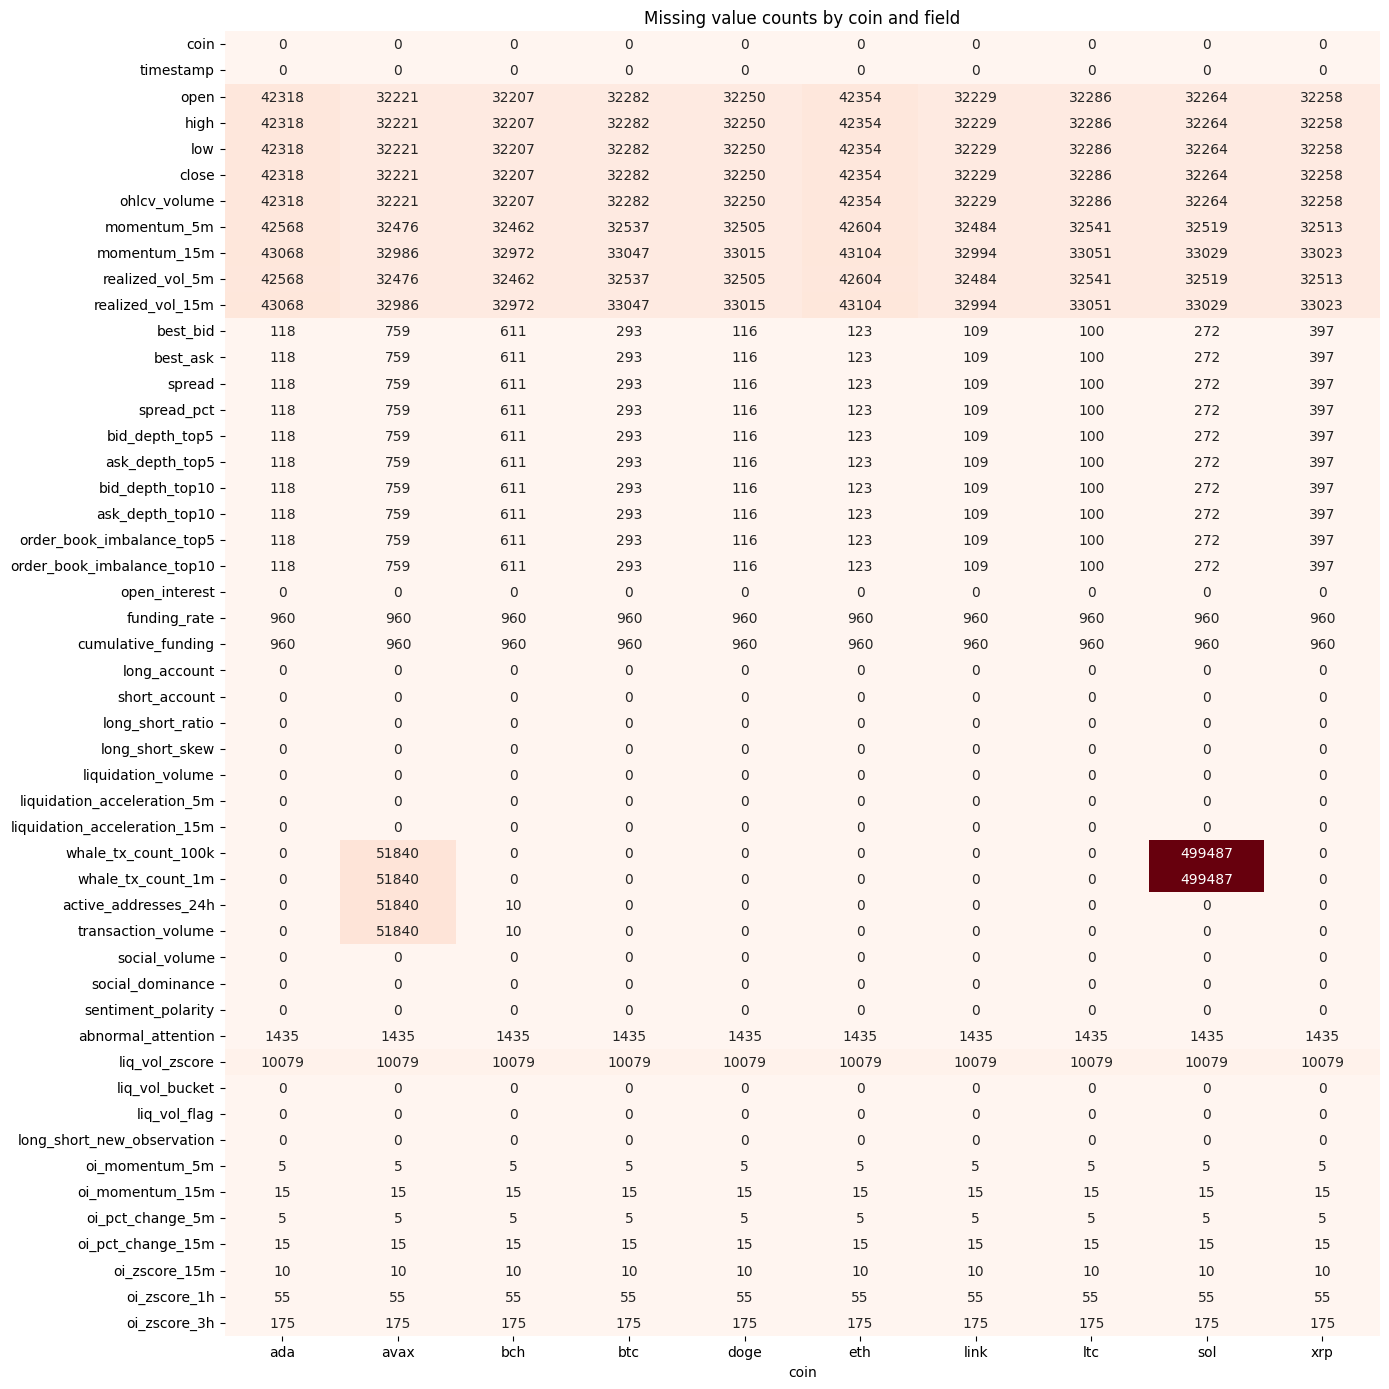

In [15]:

missing_counts_by_coin = df.groupby('coin').apply(lambda g: g.isna().sum())
plt.figure(figsize=(14, 14))
sns.heatmap(missing_counts_by_coin.T, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("Missing value counts by coin and field")
plt.tight_layout()
plt.show()

### Line charts on Open to see gaps, found gaps towards end for all coins, and big gaps for ETH and ADA around 2026-Feb

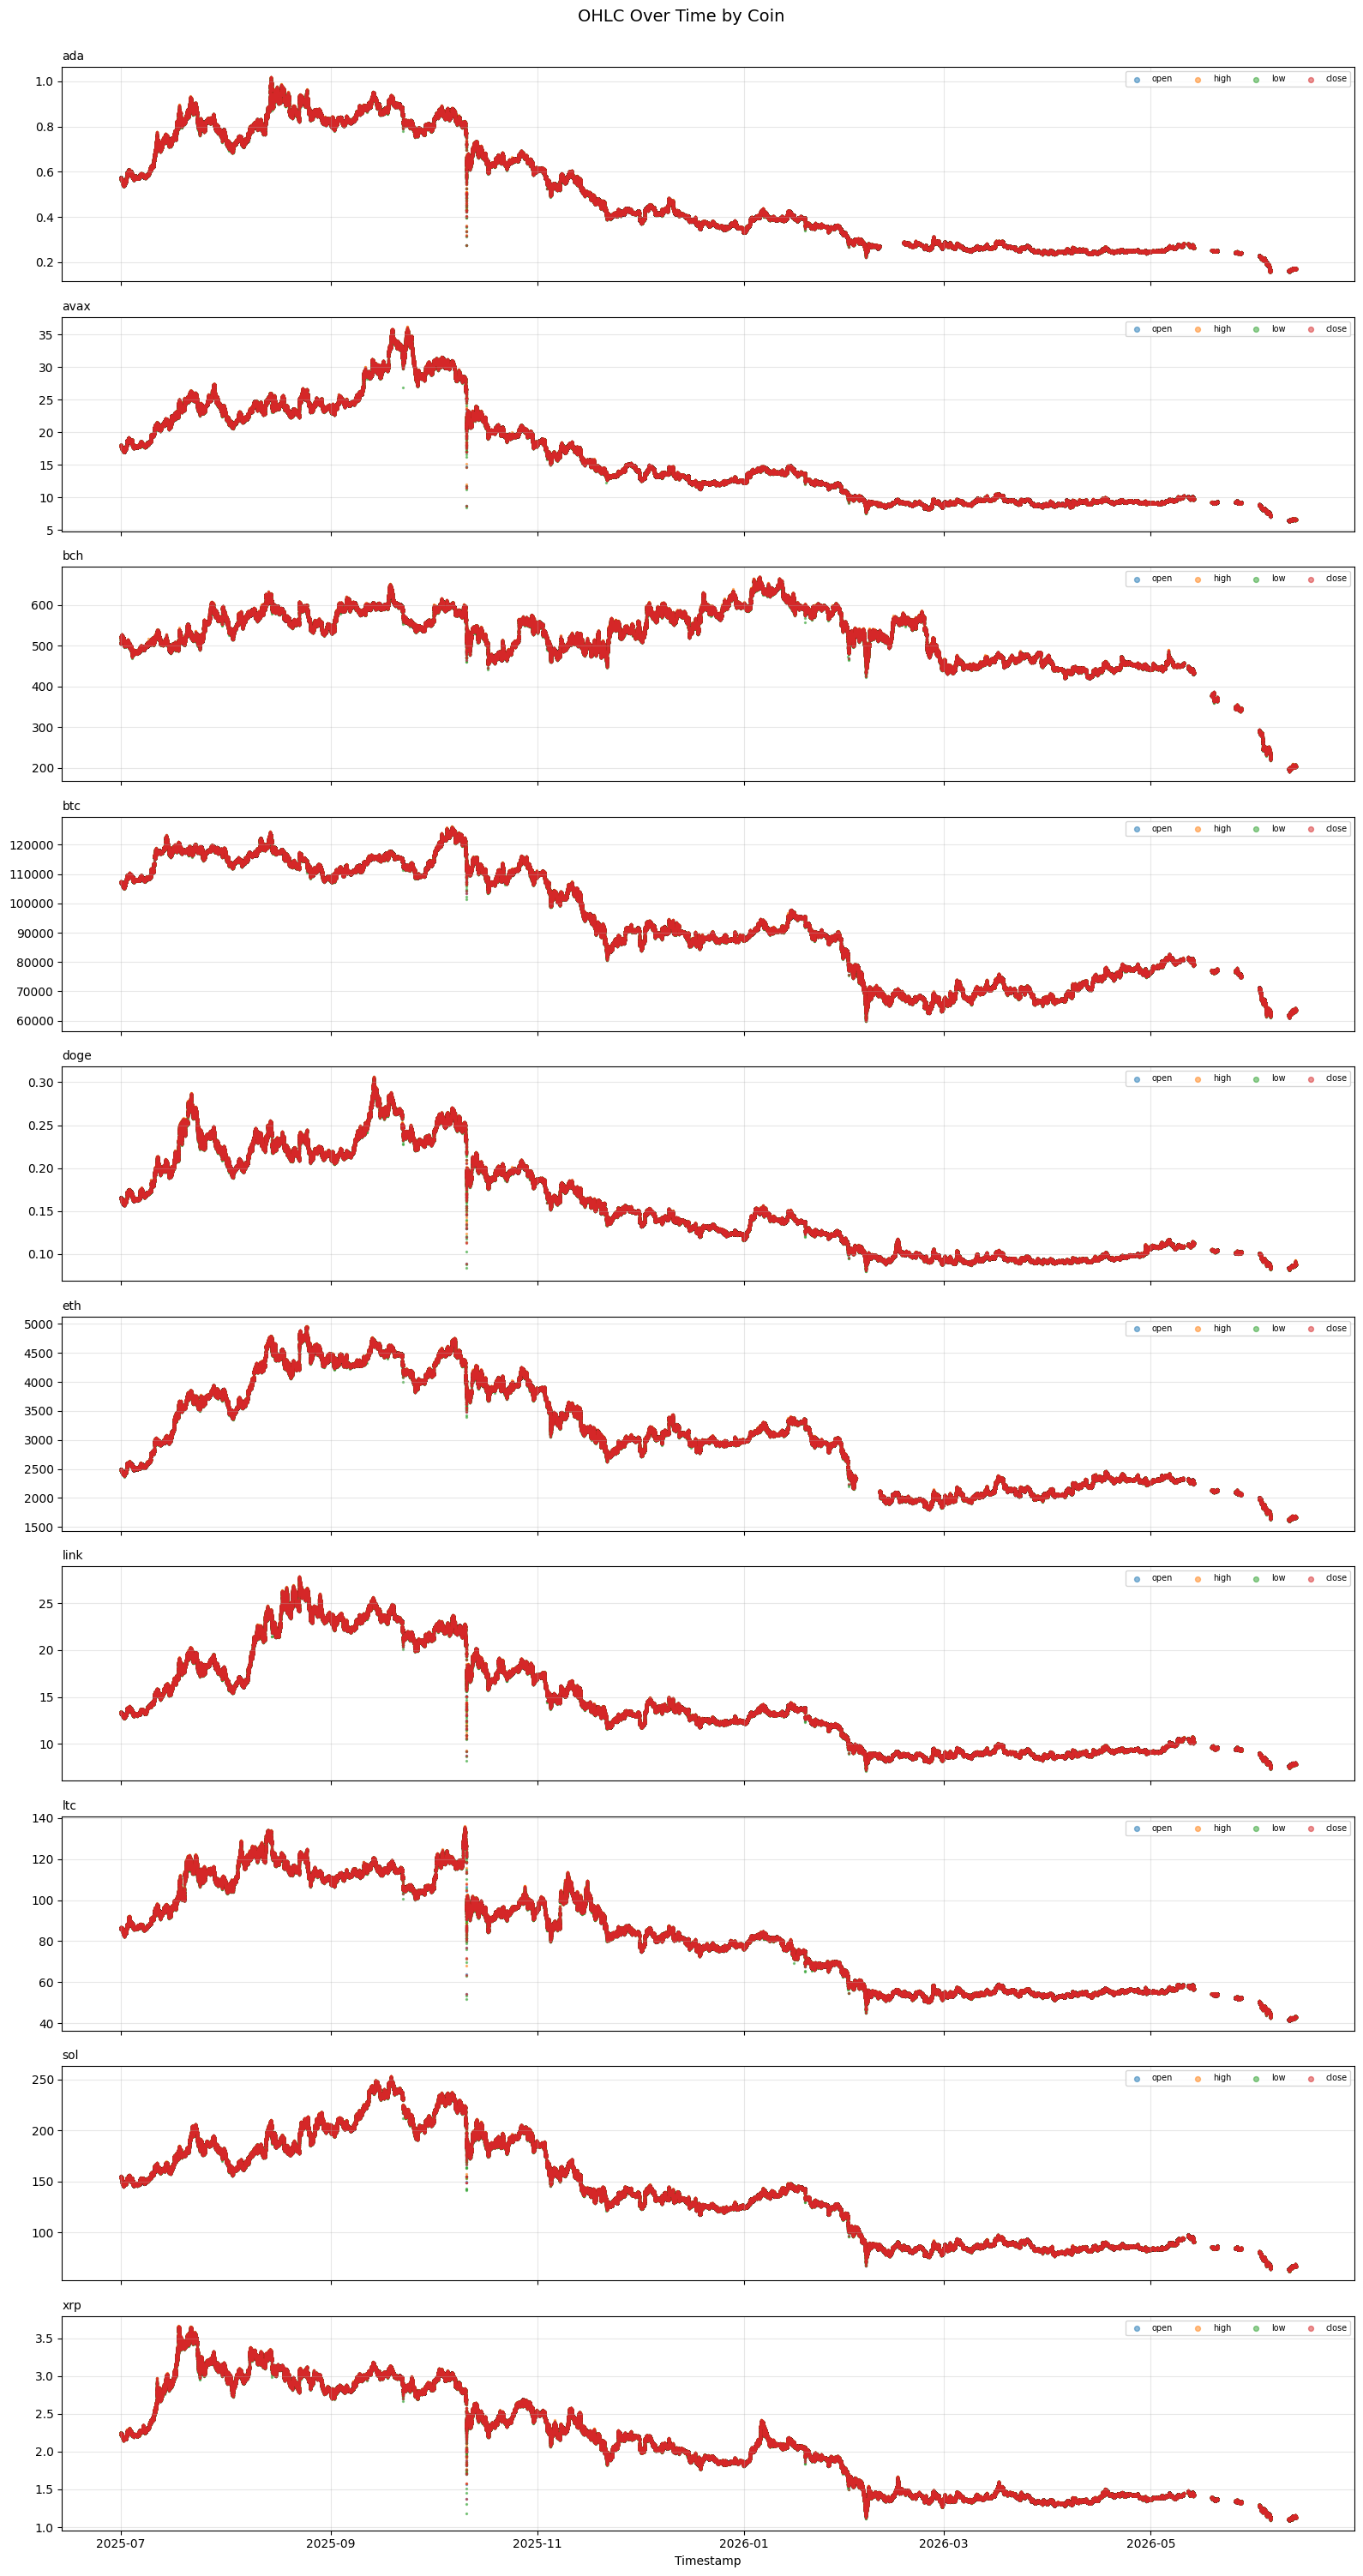

In [16]:

df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')

fig, axes = plt.subplots(len(df['coin'].unique()), 1, figsize=(16, 3 * df['coin'].nunique()), sharex=True)

for ax, (coin, group) in zip(axes, df.groupby('coin')):
    group = group.sort_values('timestamp')

    ax.scatter(group['timestamp'], group['open'], label='open', s=2, alpha=0.5)
    ax.scatter(group['timestamp'], group['high'], label='high', s=2, alpha=0.5)
    ax.scatter(group['timestamp'], group['low'], label='low', s=2, alpha=0.5)
    ax.scatter(group['timestamp'], group['close'], label='close', s=2, alpha=0.5)

    ax.set_title(coin, fontsize=10, loc='left')
    ax.legend(fontsize=7, ncol=4, loc='upper right', markerscale=3)
    ax.grid(alpha=0.3)

plt.xlabel("Timestamp")
fig.suptitle("OHLC Over Time by Coin", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
timestamp_ranges = df.groupby("coin")["timestamp"].agg(["min", "max", "count"])
print(timestamp_ranges)

                           min                       max   count
coin                                                            
ada  2025-07-01 00:00:00+00:00 2026-06-12 20:48:00+00:00  499489
avax 2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
bch  2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
btc  2025-07-01 00:00:00+00:00 2026-06-12 20:50:00+00:00  499491
doge 2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
eth  2025-07-01 00:00:00+00:00 2026-06-12 20:49:00+00:00  499490
link 2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
ltc  2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
sol  2025-07-01 00:00:00+00:00 2026-06-12 20:46:00+00:00  499487
xrp  2025-07-01 00:00:00+00:00 2026-06-12 20:47:00+00:00  499488


### remove SOLANA that have no whale_tx_count_100k and whale_tx_count_1m
### also due to AVAX whale_tx_count_100k or whale_tx_count_1m coverage not having 1st July to 5th August 2025

In [18]:
%%time
# due to AVAX coverage not having 1st July to 5th August 2025, we should start dataset on 6th August 2025
df = (df[(df["coin"] != "sol") & (df["timestamp"] >= "2025-08-06 00:00:00+00:00") & (df["timestamp"] < "2026-05-10 00:00:00+00:00")].copy())

CPU times: total: 5.38 s
Wall time: 5.91 s


### Forward fill order book columns
### drop missing OHLCV
### create segments to counter when gaps larger than 1 minutes
### exclude warm-up and incomplete rows

In [19]:
%%time

df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"],utc=True,errors="coerce")
df = (df.sort_values(["coin", "timestamp"]).reset_index(drop=True))

orderbook_cols = ["best_bid",
                  "best_ask",
                  "spread",
                  "spread_pct",
                  "bid_depth_top5",
                  "ask_depth_top5",
                  "bid_depth_top10",
                  "ask_depth_top10",
                  "order_book_imbalance_top5",
                  "order_book_imbalance_top10",]

orderbook_cols = [col for col in orderbook_cols if col in df.columns]

# Carry the last snapshot forward for no more than two minutes
df[orderbook_cols] = (df.groupby("coin", sort=False)[orderbook_cols].ffill(limit=2))

# remove missing ohlcv rows
ohlcv_cols = ["open","high","low","close","ohlcv_volume",]
valid_ohlcv = (df[ohlcv_cols].notna().all(axis=1))
model_df = (df.loc[valid_ohlcv].copy().reset_index(drop=True))

# identify contiguous price segments
timestamp_gap = (model_df.groupby("coin", sort=False)["timestamp"].diff())
model_df["_new_price_segment"] = (timestamp_gap.ne(pd.Timedelta(minutes=1)))
model_df["price_segment_id"] = (model_df.groupby("coin", sort=False)["_new_price_segment"].cumsum())
segment_cols = ["coin","price_segment_id",]

# recalculate features within segments
model_df["log_return_1m"] = (model_df.groupby(segment_cols, sort=False)["close"].transform(lambda x: np.log(x).diff()))
model_df["momentum_5m"] = (model_df.groupby(segment_cols, sort=False)["close"].pct_change(periods=5,fill_method=None))
model_df["momentum_15m"] = (model_df.groupby(segment_cols, sort=False)["close"].pct_change(periods=15,fill_method=None))
model_df["realized_vol_5m"] = (model_df.groupby(segment_cols,sort=False)["log_return_1m"].transform(lambda x: x.rolling(window=5,min_periods=5.std()))
model_df["realized_vol_15m"] = (model_df.groupby(segment_cols,sort=False)["log_return_1m"].transform(lambda x: x.rolling(window=15,min_periods=15).std()))

# drop warm up rows
price_feature_cols = ["momentum_5m","momentum_15m","realized_vol_5m","realized_vol_15m",]
required_cols = (ohlcv_cols+ price_feature_cols+ orderbook_cols)
rows_before = len(model_df)
model_df = (model_df.dropna(subset=required_cols).reset_index(drop=True))

rows_after = len(model_df)

print(f"Rows before final removal: {rows_before:,}")
print(f"Rows after final removal:  {rows_after:,}")
print(f"Rows removed:              {rows_before - rows_after:,}")
print("Percentage removed:",round((rows_before - rows_after)/ rows_before* 100,4),"%")

# remove temporary columns
model_df = model_df.drop(columns=["_ohlcv_missing","_missing_run","_new_price_segment","log_return_1m",],errors="ignore")

remaining_missing = pd.DataFrame({"nan_count": model_df.isna().sum(),"nan_percentage": model_df.isna().mean() * 100,})
remaining_missing = remaining_missing[remaining_missing["nan_count"] > 0].sort_values("nan_percentage",ascending=False)
print(remaining_missing)

Rows before final removal: 3,569,760
Rows after final removal:  3,569,288
Rows removed:              472
Percentage removed: 0.0132 %
Empty DataFrame
Columns: [nan_count, nan_percentage]
Index: []
CPU times: total: 16.5 s
Wall time: 16.8 s


### add extra OI features

In [20]:
%%time

# Ensure correct ordering
model_df = (model_df.sort_values(["coin", "timestamp"]).copy())
group = model_df.groupby("coin", sort=False)
print("sorted")

# Volatility acceleration
model_df["volatility_acceleration"] = (model_df["realized_vol_5m"]- model_df["realized_vol_15m"])
print("volatility_acceleration")

model_df["volatility_ratio"] = (model_df["realized_vol_5m"] / (model_df["realized_vol_15m"]+ 1e-9))
print("volatility_ratio")

# Open interest acceleration
model_df["oi_acceleration"] = (model_df["oi_momentum_5m"]- model_df["oi_momentum_15m"])
print("oi_acceleration")

# Spread relative to volatility
model_df["spread_volatility_ratio"] = ( model_df["spread_pct"]/ (model_df["realized_vol_5m"] + 1e-9))
print("spread_volatility_ratio")

# OI × volatility interaction
model_df["oi_volatility_interaction"] = (model_df["open_interest"] * model_df["realized_vol_5m"])
print("oi_volatility_interaction")

# Final summary
new_features = ["volatility_acceleration","volatility_ratio","oi_acceleration","spread_volatility_ratio","oi_volatility_interaction",]
            
print("Created", len(new_features), "new features:\n")

display(model_df[new_features].head())

sorted
volatility_acceleration
volatility_ratio
oi_acceleration
spread_volatility_ratio
oi_volatility_interaction
Created 5 new features:


Preview


,volatility_acceleration,volatility_ratio,oi_acceleration,spread_volatility_ratio,oi_volatility_interaction
0,0.000173,1.252774,97337.0,0.161604,239107.968960
1,0.000168,1.243329,97337.0,0.161605,239106.932190
2,0.000206,1.269849,97337.0,0.142423,271234.717405
3,0.000132,1.185451,97337.0,0.163877,236118.303246
4,0.000265,1.305892,97337.0,0.122534,315741.615067


CPU times: total: 2.12 s
Wall time: 2.17 s


### Add order-book depth totals if needed

In [21]:
model_df["total_depth_top5"] = (model_df["bid_depth_top5"]+ model_df["ask_depth_top5"])
model_df["total_depth_top10"] = (model_df["bid_depth_top10"]+ model_df["ask_depth_top10"])

### Export dataset!

In [22]:
model_df.to_csv("crypto_master_dataset_imputed.csv", index=False)